# Operator Dynamics in Random Bricklayer Circuits Noisy with Pauli Propagation and MPO

The goal of this notebook is to study the time evolution of a local quantum observable using the Pauli propagation framework implemented in `PauliPropagation.jl` and compare it to the MPO method.

In [234]:
# using Pkg; Pkg.add("LaTeXStrings"); Pkg.add("PauliPropagation"); Pkg.add("ITensors"); Pkg.add("ITensorMPS")

In [235]:
using LaTeXStrings
using Plots
using LinearAlgebra
import Statistics: mean

# --- Pauli Propagation ---
using PauliPropagation

#include("../src/pauli_propagation_functions.jl")
include("pauli_propagation_functions.jl")
import .pauli_propagation_functions as pp

# --- MPO ---
using ITensors, ITensorMPS

#include("../src/matrix_product_operator_functions.jl")
include("matrix_product_operator_functions.jl")
import .mpo_functions as mpo

# --- Exact method ---
#include("../src/exact_functions.jl")
include("exact_functions.jl")
import .exact_functions as ext

# --- Circuit ---
#include("../src/circuit.jl")
include("circuit.jl")
import .circuit as ct

In [236]:
nqubits = 7
nlayers = 50

50

In [237]:
circuit_pp, circuit_mpo, circuit_exact, sites = ct.random_circuit(nqubits, nlayers)

Z_2 = PauliString(nqubits, :Z, 2) # IZI...I
observable = Z_2

PauliString(nqubits: 7, 1.0 * IZIIIII)

In [238]:
γ_list = 0:0.2:1
entropy = Vector{Float64}[]
for γ in γ_list
  psum, result = pp.propagate_layerbylayer(circuit_pp, observable, nlayers; max_weight=nqubits, min_abs_coeff=1e-6, applyNoise=true, γ)
  push!(entropy, result["S"])
end

layer : 5/50 complete
layer : 10/50 complete
layer : 15/50 complete
layer : 20/50 complete
layer : 25/50 complete
layer : 30/50 complete
layer : 35/50 complete
layer : 40/50 complete
layer : 45/50 complete
layer : 50/50 complete
Time taken by pp.propagate_layerbylayer: 12.943248987197876 seconds
layer : 5/50 complete
layer : 10/50 complete
layer : 15/50 complete
layer : 20/50 complete
layer : 25/50 complete
layer : 30/50 complete
layer : 35/50 complete
layer : 40/50 complete
layer : 45/50 complete
layer : 50/50 complete
Time taken by pp.propagate_layerbylayer: 13.205251932144165 seconds
layer : 5/50 complete
layer : 10/50 complete
layer : 15/50 complete
layer : 20/50 complete
layer : 25/50 complete
layer : 30/50 complete
layer : 35/50 complete
layer : 40/50 complete
layer : 45/50 complete
layer : 50/50 complete
Time taken by pp.propagate_layerbylayer: 12.872428894042969 seconds
layer : 5/50 complete
layer : 10/50 complete
layer : 15/50 complete
layer : 20/50 complete
layer : 25/50 comp

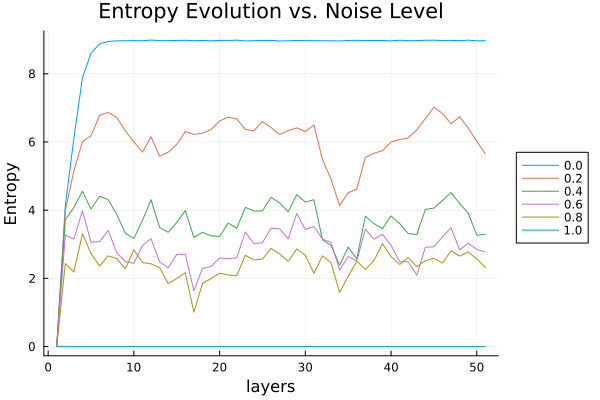

In [239]:
plot(entropy,
    label=γ_list',
    title="Entropy Evolution vs. Noise Level",
    xlabel="layers",
    ylabel="Entropy",
    lw=1,
    legend=:outerright
)

---

# Noise

In [240]:
function applynoiselayer(psum::PauliSum;depol_strength=0.02, dephase_strength=0.02, noise_level=1.0)
    for (pstr, coeff) in psum
        set!(psum, pstr,
            coeff*(1-noise_level*depol_strength)^countweight(pstr)*(1-noise_level*dephase_strength)^countxy(pstr))
    end
end

applynoiselayer (generic function with 1 method)

For the noisy circuits, we'll define a function `applynoiselayer`, which adds depolarizing and dephasing noise in the Pauli Transfer Matrix (PTM) formalism.

In Pauli Propagation, there is also a higher level noise implementation, which looks for example like this: `depol_noise_layer = [DepolarizingNoise(qind, depol_strength) for qind in 1:nq];`. This gives the same results as our code, but requires to loop over the number of qubits for both noise kinds, so we instead opt for the `applynoiselayer` implementation above, equivalent to the one in Pauli Propagation under the hood.

Note that the `depol_strength` (and `dephase_strength`) arguments in the `applynoiselayer` function are not simply the single gate error probabilites as one might assume, rather they are related to those via a multiplicative factor which depends on the noise kind. You can safely skip this section for now, but it will be useful if you are trying to implement a circuit with certain gate error probabilities.

---

## References

- https://arxiv.org/abs/2505.21606
- https://github.com/MSRudolph/PauliPropagation.jl
- https://arxiv.org/abs/math-ph/0609050
- [Julia documentation](https://docs.julialang.org/en/v1/)
- [Plots documentation](https://docs.juliaplots.org/stable/)
- [LinearAlgebra documentation](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/)
- [LaTeXStrings documentation](https://juliapackages.com/p/latexstrings)
- Latex Tiks documentation https://www.overleaf.com/learn/latex/LaTeX_Graphics_using_TikZ%3A_A_Tutorial_for_Beginners_(Part_3)%E2%80%94Creating_Flowcharts


  - https://github.com/MSRudolph/PauliPropagation.jl/blob/main/examples/introduction-example-error-mitigation.ipynb